# **Modelos Supervisados**

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

ruta_preparado = Path("../PREPROCESAMIENTO_LIMPIEZA_DATOS/8_dataset_preparado_ml.csv")
ruta_transformado = Path("../PREPROCESAMIENTO_LIMPIEZA_DATOS/7_dataset_transformado.csv")
ruta_limpio = Path("../PREPROCESAMIENTO_LIMPIEZA_DATOS/6_dataset_limpio.csv")

df_preparado = pd.read_csv(ruta_preparado)

print("Dataset preparado:")
print("Registros:", df_preparado.shape[0])
print("Columnas:", df_preparado.shape[1])

df_preparado.head()

Dataset preparado:
Registros: 87370
Columnas: 31


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1.25457,-0.615833,3.045556,-1.763984,-0.085098,0.011736,-1.676934,-0.974301,-1.278582,0.198010,...,3.751152,-0.111309,-0.736861,-0.07485,-0.105748,-1.933442,-0.299218,-0.839768,0.547314,-1.971705
1,1.25457,-0.615833,7.635592,-1.763984,-0.085098,0.011736,-1.676934,-0.974301,-1.278582,0.198010,...,5.126043,-0.111309,-0.736861,-0.07485,-0.105748,-1.933442,-0.299218,-0.839768,0.547314,-1.971705
2,1.25457,-0.615833,-0.847259,-1.763984,-0.085098,0.011736,-1.676934,-0.974301,-0.791651,-1.398237,...,-0.373520,-0.111309,-0.736861,-0.07485,-0.105748,-0.569903,-0.299218,-0.839768,0.547314,-1.967091
3,1.25457,-0.615833,-0.777537,-1.763984,-0.085098,0.011736,-1.676934,-0.974301,-0.791651,-1.398237,...,-0.373520,-0.111309,2.028261,-0.07485,-0.105748,-0.569903,-0.299218,-0.839768,0.547314,-1.967091
4,1.25457,-0.615833,-0.765916,-1.763984,-0.085098,0.011736,-1.676934,-0.974301,-0.304720,0.198010,...,-0.373520,-0.111309,1.446130,-0.07485,-0.105748,-0.151752,-0.299218,0.362239,0.547314,-1.962476


In [ ]:
print("Valores únicos de is_canceled en dataset preparado:")
print(df_preparado["is_canceled"].value_counts().head(10))

print("\nMínimo:", df_preparado["is_canceled"].min())
print("Máximo:", df_preparado["is_canceled"].max())

Valores únicos de is_canceled en dataset preparado:
is_canceled
-0.615833    63346
 1.623816    24024
Name: count, dtype: int64

Mínimo: -0.6158331476108885
Máximo: 1.6238164572327398


In [ ]:
df_transformado = pd.read_csv(ruta_transformado)

print("Dataset transformado:")
print("Registros:", df_transformado.shape[0])
print("Columnas:", df_transformado.shape[1])

print("\nValores únicos de is_canceled:")
print(df_transformado["is_canceled"].value_counts().head(10))

df_transformado.head()

Dataset transformado:
Registros: 87370
Columnas: 31

Valores únicos de is_canceled:
is_canceled
0    63346
1    24024
Name: count, dtype: int64


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,booking_changes,deposit_type,agent,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,1,0,342,2015,5,27,1,0,0,2,...,3,0,0.0,0,2,0.0,0,0,1,121
1,1,0,737,2015,5,27,1,0,0,2,...,4,0,0.0,0,2,0.0,0,0,1,121
2,1,0,7,2015,5,27,1,0,1,1,...,0,0,0.0,0,2,75.0,0,0,1,122
3,1,0,13,2015,5,27,1,0,1,1,...,0,0,304.0,0,2,75.0,0,0,1,122
4,1,0,14,2015,5,27,1,0,2,2,...,0,0,240.0,0,2,98.0,0,1,1,123


In [ ]:
# Definir X e y para el modelado supervisado

# X viene del dataset preparado/escalado
X = df_preparado.copy()

# y viene del dataset transformado porque conserva is_canceled como 0 y 1
y = df_transformado["is_canceled"].copy()

# Eliminar la variable objetivo de X si existe
if "is_canceled" in X.columns:
    X = X.drop(columns=["is_canceled"])

# Eliminar posibles columnas que generan fuga de información
# reservation_status puede revelar directamente si la reserva fue cancelada
columnas_a_eliminar = [
    "reservation_status",
    "reservation_status_date"
]

for col in columnas_a_eliminar:
    if col in X.columns:
        X = X.drop(columns=[col])

print("Tamaño de X:", X.shape)
print("Tamaño de y:", y.shape)

print("\nValores de y:")
print(y.value_counts())

Tamaño de X: (87370, 28)
Tamaño de y: (87370,)

Valores de y:
is_canceled
0    63346
1    24024
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# División del dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

print("\nDistribución de clases en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nDistribución de clases en prueba:")
print(y_test.value_counts(normalize=True))


Tamaño de X_train: (69896, 28)
Tamaño de X_test: (17474, 28)
Tamaño de y_train: (69896,)
Tamaño de y_test: (17474,)

Distribución de clases en entrenamiento:
is_canceled
0    0.725034
1    0.274966
Name: proportion, dtype: float64

Distribución de clases en prueba:
is_canceled
0    0.72502
1    0.27498
Name: proportion, dtype: float64


#### Modelo A - Regresión Logística

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Modelo A: Regresión Logística
modelo_logistico = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Entrenamiento del modelo
modelo_logistico.fit(X_train, y_train)

# Predicciones
y_pred_logistico = modelo_logistico.predict(X_test)

# Métricas
accuracy_logistico = accuracy_score(y_test, y_pred_logistico)
precision_logistico = precision_score(y_test, y_pred_logistico)
recall_logistico = recall_score(y_test, y_pred_logistico)
f1_logistico = f1_score(y_test, y_pred_logistico)

print("Resultados - Regresión Logística")
print("Accuracy:", accuracy_logistico)
print("Precision:", precision_logistico)
print("Recall:", recall_logistico)
print("F1-score:", f1_logistico)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_logistico))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_logistico))


Resultados - Regresión Logística
Accuracy: 0.7757239327000115
Precision: 0.6690839694656489
Recall: 0.3648283038501561
F1-score: 0.4721885521885522

Matriz de confusión:
[[11802   867]
 [ 3052  1753]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.93      0.86     12669
           1       0.67      0.36      0.47      4805

    accuracy                           0.78     17474
   macro avg       0.73      0.65      0.66     17474
weighted avg       0.76      0.78      0.75     17474



La Regresión Logística tuvo una precisión general aceptable, cercana al 78%, pero, el modelo detecta mejor las reservas no canceladas que las canceladas, por eso se entrenará un segundo modelo más robusto para comparar resultados.

#### Modelo B - Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Modelo B: Random Forest
modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento del modelo
modelo_random_forest.fit(X_train, y_train)

# Predicciones
y_pred_rf = modelo_random_forest.predict(X_test)

# Métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Resultados - Random Forest")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_rf))

Resultados - Random Forest
Accuracy: 0.8523520659265194
Precision: 0.7736777367773677
Recall: 0.6545265348595213
F1-score: 0.7091319052987599

Matriz de confusión:
[[11749   920]
 [ 1660  3145]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90     12669
           1       0.77      0.65      0.71      4805

    accuracy                           0.85     17474
   macro avg       0.82      0.79      0.81     17474
weighted avg       0.85      0.85      0.85     17474



Random Forest es el mejor modelo, porque obtuvo mejores resultados en todas las métricas principales:
- Mayor accuracy.
- Mayor precision.
- Mayor recall.
- Mayor F1-score.

Tambien, detecta mucho mejor las reservas canceladas, en Regresión Logística el recall para la clase cancelada era bajo, alrededor de 0.36, mientras que en Random Forest subió a 0.65.

#### Tabla comparativa de modelos

In [ ]:
# Comparación de modelos

resultados_modelos = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [accuracy_logistico, accuracy_rf],
    "Precision": [precision_logistico, precision_rf],
    "Recall": [recall_logistico, recall_rf],
    "F1-score": [f1_logistico, f1_rf]
})

resultados_modelos

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.775724,0.669084,0.364828,0.472189
1,Random Forest,0.852352,0.773678,0.654527,0.709132


In [ ]:
from pathlib import Path

# Crear carpeta de resultados si no existe
carpeta_resultados = Path("resultados")
carpeta_resultados.mkdir(exist_ok=True)

# Guardar tabla de métricas
ruta_metricas = carpeta_resultados / "metricas_modelos_supervisados.csv"
resultados_modelos.to_csv(ruta_metricas, index=False)

print("Tabla de métricas guardada en:", ruta_metricas)

Tabla de métricas guardada en: resultados\metricas_modelos_supervisados.csv


#### PNG de matrices de confusión

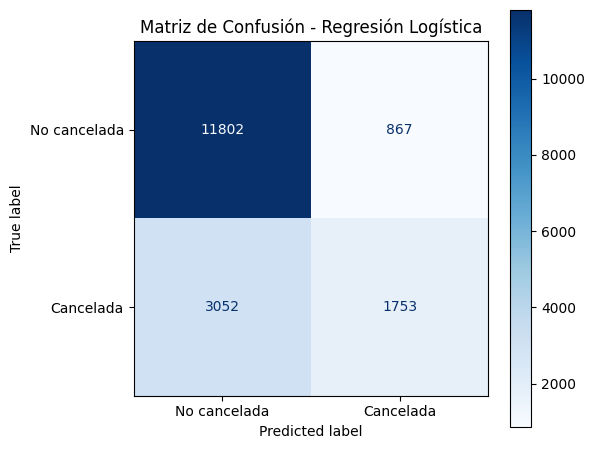

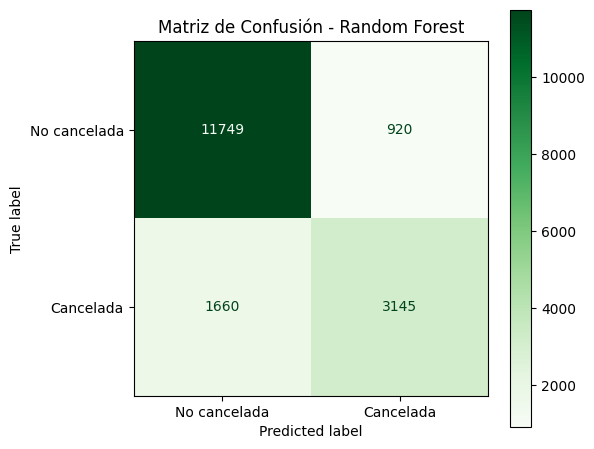

Matrices de confusión guardadas correctamente.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from pathlib import Path

# Crear carpeta de resultados si no existe
carpeta_resultados = Path("resultados")
carpeta_resultados.mkdir(exist_ok=True)

# Matriz de confusión - Regresión Logística
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistico,
    display_labels=["No cancelada", "Cancelada"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Matriz de Confusión - Regresión Logística")
plt.tight_layout()
plt.savefig(carpeta_resultados / "matriz_confusion_regresion_logistica.png", dpi=300)
plt.show()

# Matriz de confusión - Random Forest
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No cancelada", "Cancelada"],
    cmap="Greens",
    ax=ax
)
ax.set_title("Matriz de Confusión - Random Forest")
plt.tight_layout()
plt.savefig(carpeta_resultados / "matriz_confusion_random_forest.png", dpi=300)
plt.show()

print("Matrices de confusión guardadas correctamente.")

#### PNG de comparación de modelos

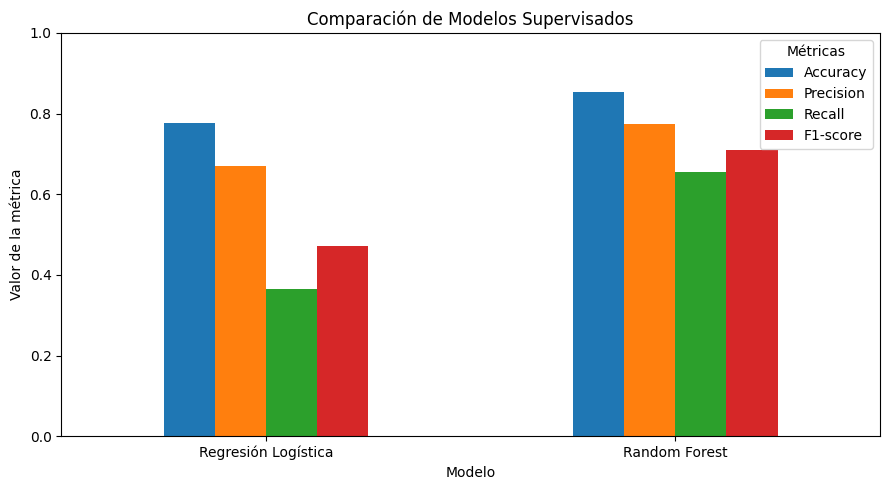

Gráfico comparativo guardado correctamente.


In [ ]:
# Gráfico comparativo de métricas

metricas_plot = resultados_modelos.set_index("Modelo")

ax = metricas_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Comparación de Modelos Supervisados")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métricas")
plt.tight_layout()

plt.savefig(carpeta_resultados / "comparacion_modelos_supervisados.png", dpi=300)
plt.show()

print("Gráfico comparativo guardado correctamente.")